# Analisis Waktu Pengujian Stasiun (Takt Log Time)

Notebook ini menganalisis data pengujian produksi yang tersimpan dalam 4 tabel yang saling berelasi (ERD):

- **cell_master** — daftar Cell/lini produksi
- **station_master** — daftar Stasiun, tiap stasiun terhubung ke satu Cell (`CellID`)
- **meter_type_master** — jenis alat ukur/tipe pengujian
- **takt_log_time** — log waktu pengujian tiap unit (`SerialNumber`) di tiap stasiun, berisi `StartTime` dan `EndTime`

Hasil analisis mencakup:
1. Average Per Station
2. Total Test
3. Waiting Time
4. Utilization
5. Value-Add dan Non-Value-Add Time


In [1]:
# =========================================================
# 0. Import Library
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, os

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (11, 5)


In [2]:
# =========================================================
# 1. Load Data
# =========================================================
# Jika di Google Colab dan file masih berupa DummyCsv.zip, jalankan blok upload berikut:
#
# from google.colab import files
# uploaded = files.upload()   # pilih DummyCsv.zip

ZIP_PATH = "DummyCsv.zip"     # sesuaikan lokasi file zip
EXTRACT_DIR = "DummyCsv"

if os.path.exists(ZIP_PATH) and not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")

# Cari folder yang berisi CSV (menangani kemungkinan nested folder hasil ekstraksi)
def find_csv_dir(root):
    for dirpath, _, filenames in os.walk(root):
        if "takt_log_time.csv" in filenames:
            return dirpath
    return root

base = find_csv_dir(EXTRACT_DIR) + "/"

cell = pd.read_csv(base + "cell_master.csv")
station = pd.read_csv(base + "station_master.csv")
meter = pd.read_csv(base + "meter_type_master.csv")
log = pd.read_csv(base + "takt_log_time.csv", parse_dates=["StartTime", "EndTime"])

print("cell_master:", cell.shape)
print("station_master:", station.shape)
print("meter_type_master:", meter.shape)
print("takt_log_time:", log.shape)
log.head()


cell_master: (4, 2)
station_master: (20, 3)
meter_type_master: (3, 2)
takt_log_time: (405, 6)


,ID,StationID,MeterTypeID,SerialNumber,StartTime,EndTime
0,1,9,2,SN-0139,2026-08-01 08:00:33,2026-08-01 08:02:52
1,2,10,2,SN-0152,2026-08-01 08:00:50,2026-08-01 08:01:34
2,3,20,1,SN-0375,2026-08-01 08:00:58,2026-08-01 08:01:33
3,4,19,3,SN-0343,2026-08-01 08:01:13,2026-08-01 08:02:46
4,5,4,3,SN-0057,2026-08-01 08:01:19,2026-08-01 08:03:17


In [3]:
# =========================================================
# 2. Gabungkan Tabel Sesuai ERD
# =========================================================
# station_master.CellID -> cell_master.ID
station_full = station.merge(cell, left_on="CellID", right_on="ID", suffixes=("_station", "_cell"))
station_full["StationLabel"] = station_full["CellName"] + " | " + station_full["StationName"]

# takt_log_time.StationID -> station_master.ID
# takt_log_time.MeterTypeID -> meter_type_master.ID
df = log.merge(
    station_full[["ID_station", "StationLabel", "CellName", "StationName"]],
    left_on="StationID", right_on="ID_station", how="left"
)
df = df.merge(
    meter.rename(columns={"ID": "MeterTypeID", "Name": "MeterTypeName"}),
    on="MeterTypeID", how="left"
)

# Durasi tiap pengujian (detik)
df["Duration_s"] = (df["EndTime"] - df["StartTime"]).dt.total_seconds()

# Urutan stasiun sesuai StationID, dipakai konsisten di semua chart
station_order = station_full.sort_values("ID_station")["StationLabel"].tolist()

df.head()


,ID,StationID,MeterTypeID,SerialNumber,StartTime,EndTime,ID_station,StationLabel,CellName,StationName,MeterTypeName,Duration_s
0,1,9,2,SN-0139,2026-08-01 08:00:33,2026-08-01 08:02:52,9,Cell-B | Station-04,Cell-B,Station-04,MT-B,139.0
1,2,10,2,SN-0152,2026-08-01 08:00:50,2026-08-01 08:01:34,10,Cell-B | Station-05,Cell-B,Station-05,MT-B,44.0
2,3,20,1,SN-0375,2026-08-01 08:00:58,2026-08-01 08:01:33,20,Cell-D | Station-05,Cell-D,Station-05,MT-A,35.0
3,4,19,3,SN-0343,2026-08-01 08:01:13,2026-08-01 08:02:46,19,Cell-D | Station-04,Cell-D,Station-04,MT-C,93.0
4,5,4,3,SN-0057,2026-08-01 08:01:19,2026-08-01 08:03:17,4,Cell-A | Station-04,Cell-A,Station-04,MT-C,118.0


## 1. Average Per Station

Rata-rata durasi pengujian (`EndTime - StartTime`) untuk setiap stasiun.

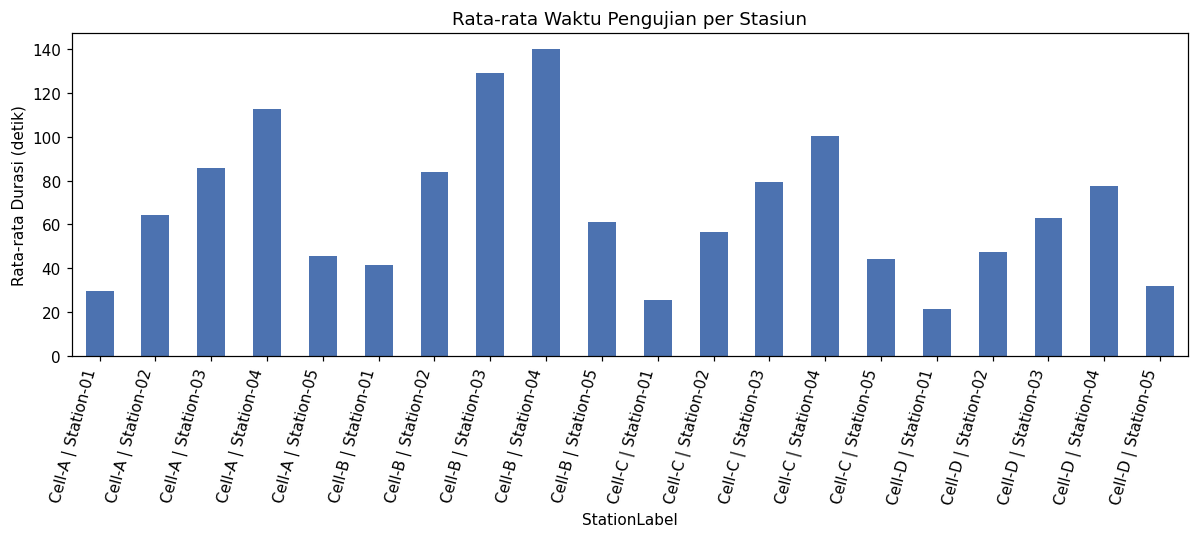

,Avg_Duration_s
StationLabel,
Cell-A | Station-01,29.777778
Cell-A | Station-02,64.095238
Cell-A | Station-03,85.588235
Cell-A | Station-04,112.555556
Cell-A | Station-05,45.523810
Cell-B | Station-01,41.687500
Cell-B | Station-02,84.000000
Cell-B | Station-03,129.166667
Cell-B | Station-04,140.307692


In [4]:
avg_per_station = df.groupby("StationLabel")["Duration_s"].mean().reindex(station_order)

plt.figure()
avg_per_station.plot(kind="bar", color="#4C72B0")
plt.ylabel("Rata-rata Durasi (detik)")
plt.title("Rata-rata Waktu Pengujian per Stasiun")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

avg_per_station.to_frame("Avg_Duration_s")


## 2. Total Test

Jumlah total pengujian yang dilakukan di setiap stasiun.

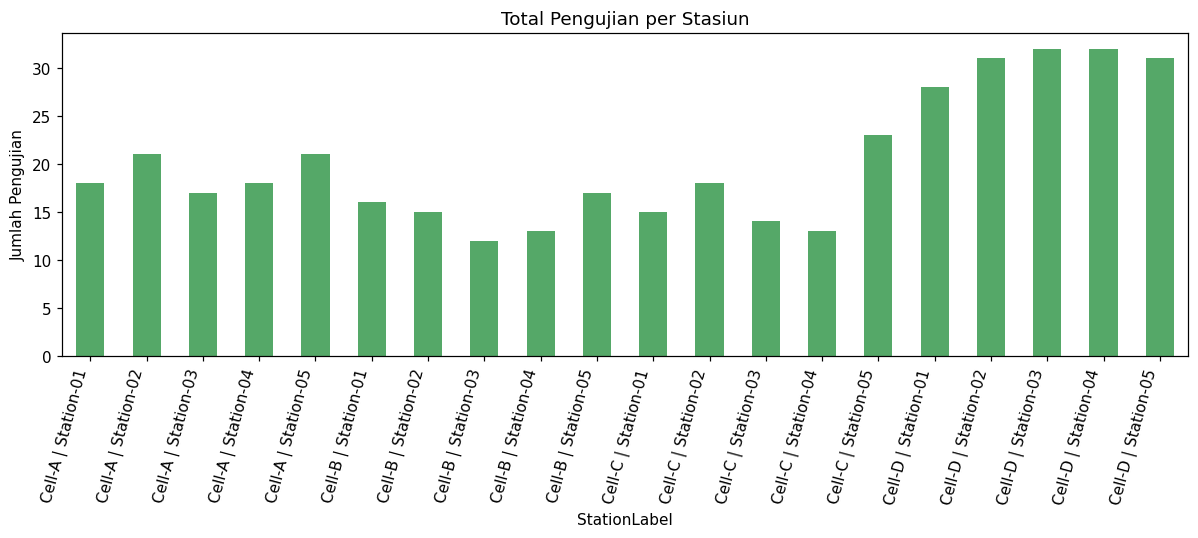

Total keseluruhan pengujian: 405


,Total_Test
StationLabel,
Cell-A | Station-01,18
Cell-A | Station-02,21
Cell-A | Station-03,17
Cell-A | Station-04,18
Cell-A | Station-05,21
Cell-B | Station-01,16
Cell-B | Station-02,15
Cell-B | Station-03,12
Cell-B | Station-04,13


In [5]:
total_test = df.groupby("StationLabel").size().reindex(station_order)

plt.figure()
total_test.plot(kind="bar", color="#55A868")
plt.ylabel("Jumlah Pengujian")
plt.title("Total Pengujian per Stasiun")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Total keseluruhan pengujian:", int(total_test.sum()))
total_test.to_frame("Total_Test")


## 3. Waiting Time

Waiting time dihitung sebagai jeda antara **EndTime pengujian sebelumnya** dan **StartTime pengujian berikutnya**
pada stasiun yang sama (idle time stasiun menunggu unit berikutnya).

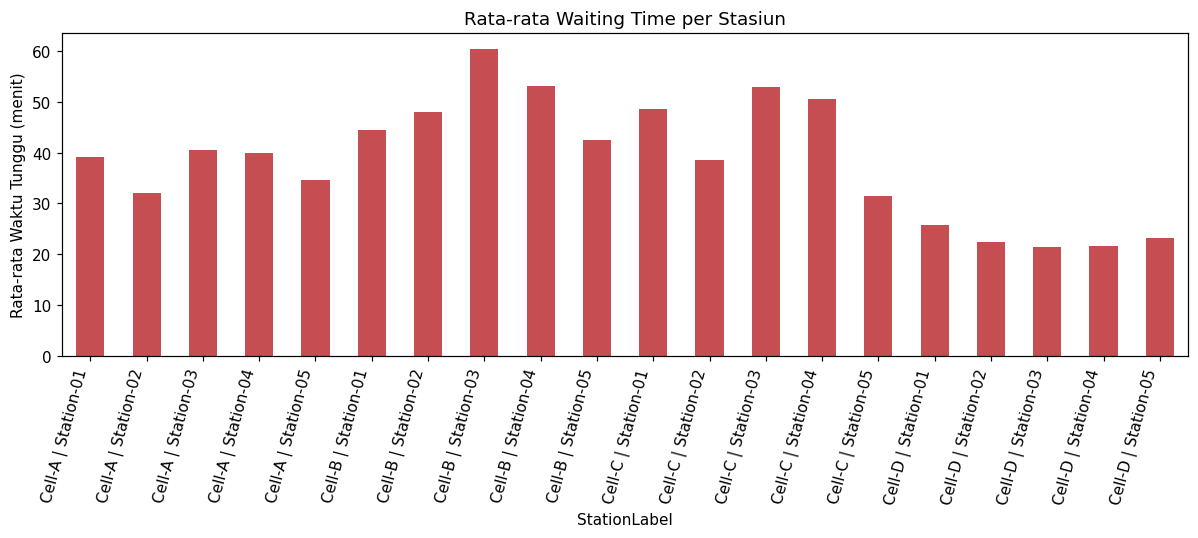

,Avg_WaitingTime_s
StationLabel,
Cell-A | Station-01,2346.705882
Cell-A | Station-02,1922.000000
Cell-A | Station-03,2428.750000
Cell-A | Station-04,2393.117647
Cell-A | Station-05,2073.450000
Cell-B | Station-01,2664.466667
Cell-B | Station-02,2879.285714
Cell-B | Station-03,3630.000000
Cell-B | Station-04,3183.416667


In [6]:
df_sorted = df.sort_values(["StationID", "StartTime"]).copy()
df_sorted["PrevEndTime"] = df_sorted.groupby("StationID")["EndTime"].shift(1)
df_sorted["WaitingTime_s"] = (df_sorted["StartTime"] - df_sorted["PrevEndTime"]).dt.total_seconds()

waiting_per_station = df_sorted.groupby("StationLabel")["WaitingTime_s"].mean().reindex(station_order)

plt.figure()
(waiting_per_station / 60).plot(kind="bar", color="#C44E52")
plt.ylabel("Rata-rata Waktu Tunggu (menit)")
plt.title("Rata-rata Waiting Time per Stasiun")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

waiting_per_station.to_frame("Avg_WaitingTime_s")


## 4. Utilization

Utilization = total waktu stasiun aktif menguji (Value-Add) dibagi total rentang waktu stasiun tersebut beroperasi
(dari pengujian pertama sampai pengujian terakhir).

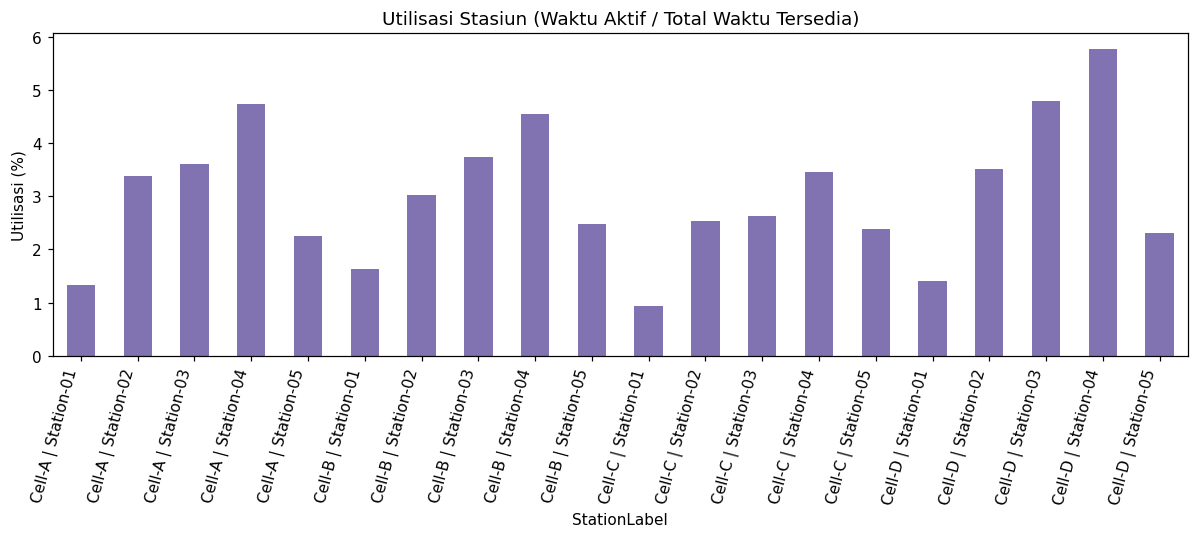

,Utilization_pct
StationLabel,
Cell-A | Station-01,1.325748
Cell-A | Station-02,3.383100
Cell-A | Station-03,3.609079
Cell-A | Station-04,4.743731
Cell-A | Station-05,2.253388
Cell-B | Station-01,1.641483
Cell-B | Station-02,3.031032
Cell-B | Station-03,3.736741
Cell-B | Station-04,4.557152


In [7]:
span = df_sorted.groupby("StationID").agg(
    first_start=("StartTime", "min"),
    last_end=("EndTime", "max"),
    total_dur=("Duration_s", "sum"),
)
span["span_s"] = (span["last_end"] - span["first_start"]).dt.total_seconds()
span["utilization_pct"] = np.where(span["span_s"] > 0, span["total_dur"] / span["span_s"] * 100, np.nan)

span = span.merge(station_full[["ID_station", "StationLabel"]], left_index=True, right_on="ID_station")
util_per_station = span.set_index("StationLabel")["utilization_pct"].reindex(station_order)

plt.figure()
util_per_station.plot(kind="bar", color="#8172B2")
plt.ylabel("Utilisasi (%)")
plt.title("Utilisasi Stasiun (Waktu Aktif / Total Waktu Tersedia)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

util_per_station.to_frame("Utilization_pct")


## 5. Value-Add dan Non-Value-Add Time

- **Value-Add (VA)**: waktu pengujian aktual (`Duration_s`) — bagian yang benar-benar memproses/menguji unit.
- **Non-Value-Add (NVA)**: waktu tunggu (`WaitingTime_s`) — stasiun idle menunggu unit berikutnya.

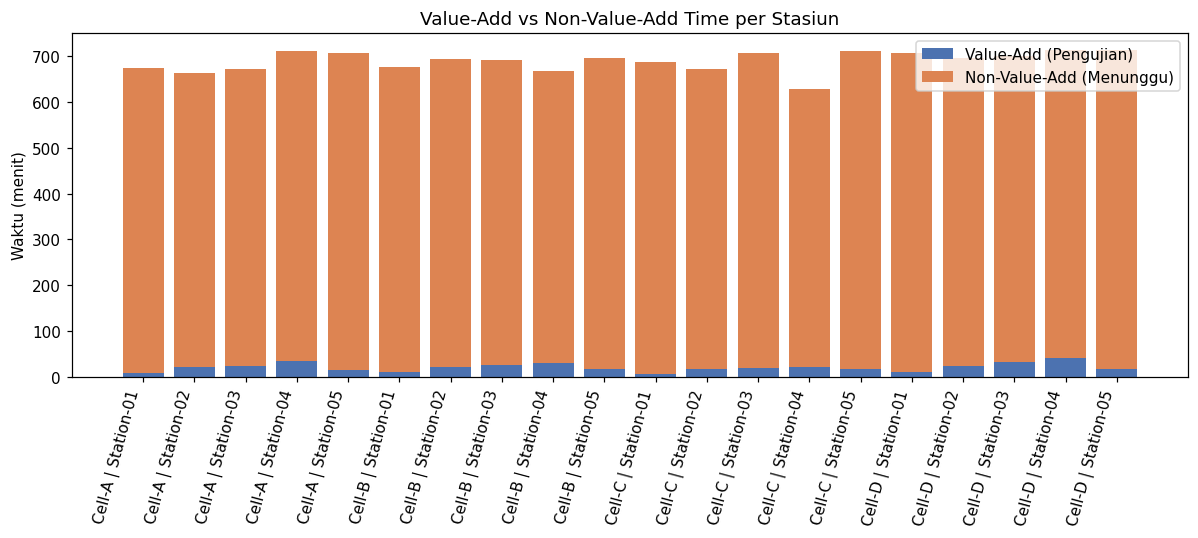

In [8]:
va_per_station = df.groupby("StationLabel")["Duration_s"].sum().reindex(station_order)
nva_per_station = df_sorted.groupby("StationLabel")["WaitingTime_s"].sum().reindex(station_order)

plt.figure()
plt.bar(station_order, va_per_station / 60, label="Value-Add (Pengujian)", color="#4C72B0")
plt.bar(station_order, nva_per_station / 60, bottom=va_per_station / 60,
        label="Non-Value-Add (Menunggu)", color="#DD8452")
plt.ylabel("Waktu (menit)")
plt.title("Value-Add vs Non-Value-Add Time per Stasiun")
plt.xticks(rotation=75, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


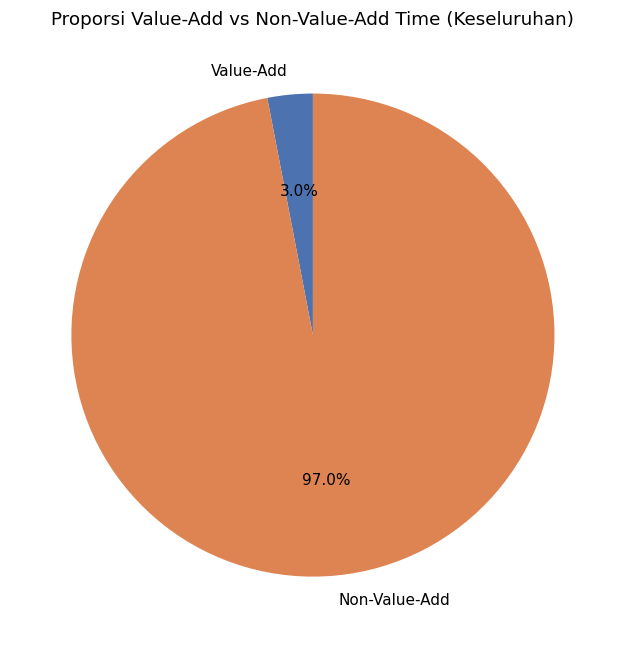

Total Value-Add time     : 417.5 menit
Total Non-Value-Add time : 13375.0 menit
Rasio Value-Add          : 3.03%


In [9]:
total_va = df["Duration_s"].sum()
total_nva = df_sorted["WaitingTime_s"].sum(skipna=True)

plt.figure(figsize=(6, 6))
plt.pie(
    [total_va, total_nva],
    labels=["Value-Add", "Non-Value-Add"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
)
plt.title("Proporsi Value-Add vs Non-Value-Add Time (Keseluruhan)")
plt.tight_layout()
plt.show()

print(f"Total Value-Add time     : {total_va/60:.1f} menit")
print(f"Total Non-Value-Add time : {total_nva/60:.1f} menit")
print(f"Rasio Value-Add          : {total_va/(total_va+total_nva)*100:.2f}%")


## Ringkasan

Tabel ringkasan berikut menggabungkan kelima metrik di atas per stasiun, dapat langsung dipakai
sebagai lampiran tabel pada laporan.

In [10]:
summary = pd.DataFrame({
    "Total_Test": total_test,
    "Avg_Duration_s": avg_per_station,
    "Avg_WaitingTime_s": waiting_per_station,
    "Utilization_pct": util_per_station,
    "Total_VA_s": va_per_station,
    "Total_NVA_s": nva_per_station,
}).round(2)

summary


,Total_Test,Avg_Duration_s,Avg_WaitingTime_s,Utilization_pct,Total_VA_s,Total_NVA_s
StationLabel,,,,,,
Cell-A | Station-01,18,29.78,2346.71,1.33,536.0,39894.0
Cell-A | Station-02,21,64.10,1922.00,3.38,1346.0,38440.0
Cell-A | Station-03,17,85.59,2428.75,3.61,1455.0,38860.0
Cell-A | Station-04,18,112.56,2393.12,4.74,2026.0,40683.0
Cell-A | Station-05,21,45.52,2073.45,2.25,956.0,41469.0
Cell-B | Station-01,16,41.69,2664.47,1.64,667.0,39967.0
Cell-B | Station-02,15,84.00,2879.29,3.03,1260.0,40310.0
Cell-B | Station-03,12,129.17,3630.00,3.74,1550.0,39930.0
Cell-B | Station-04,13,140.31,3183.42,4.56,1824.0,38201.0


---
# Tampilan Per Cell

Bagian ini menyajikan ulang kelima metrik dengan sudut pandang **per Cell**:
- Grafik **ringkasan antar Cell** (agregat 4 Cell), untuk melihat Cell mana yang paling berat/lambat/idle.
- Grafik **breakdown per stasiun di dalam tiap Cell** (subplot terpisah untuk Cell-A, B, C, D), untuk melihat detail stasiun tanpa tercampur dengan Cell lain.

In [11]:
# =========================================================
# Helper: plot per-Cell (subplot 2x2), satu subplot = satu Cell
# =========================================================
cell_names = sorted(station_full["CellName"].unique())

def plot_per_cell(series, ylabel, title, color, is_pct=False, unit_divider=1):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
    axes = axes.flatten()
    for ax, cname in zip(axes, cell_names):
        stations_in_cell = station_full.loc[station_full["CellName"] == cname]                                            .sort_values("ID_station")["StationLabel"]
        vals = (series.reindex(stations_in_cell) / unit_divider)
        labels = [s.split("| ")[-1] for s in stations_in_cell]  # cukup "Station-XX"
        ax.bar(labels, vals, color=color)
        ax.set_title(cname)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylabel(ylabel)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


## 1. Average Per Station — Per Cell

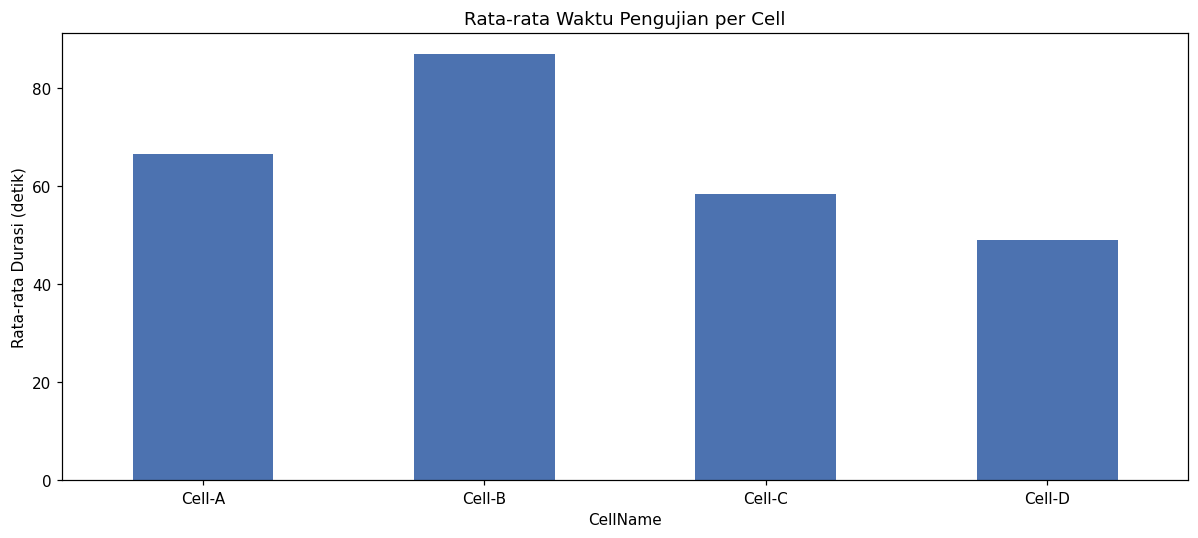

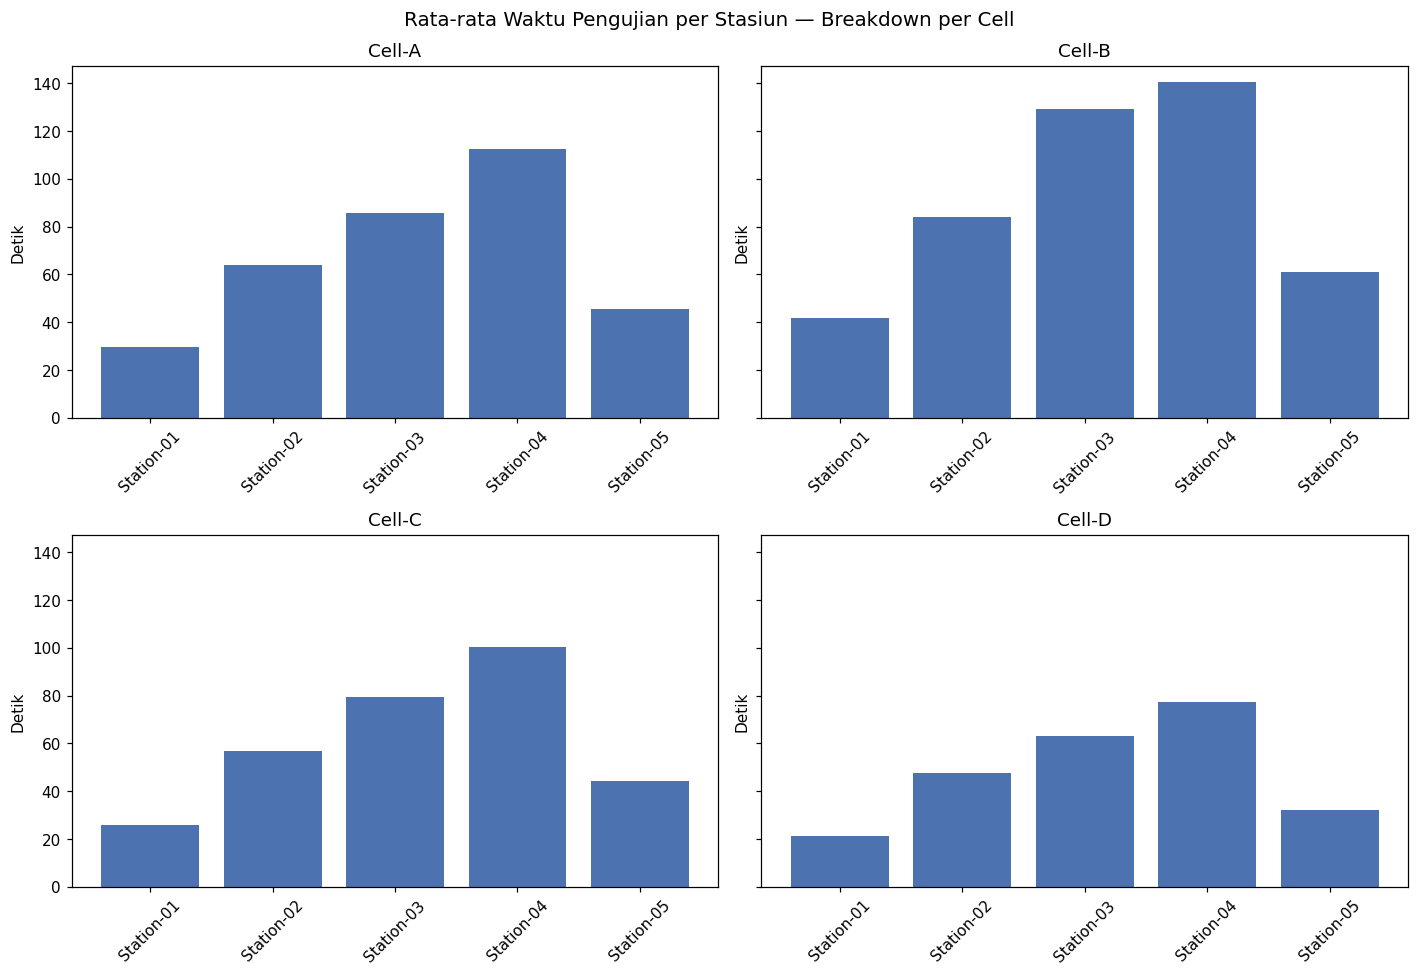

,Avg_Duration_s
CellName,
Cell-A,66.515789
Cell-B,86.849315
Cell-C,58.289157
Cell-D,49.045455


In [12]:
# Agregat antar-Cell (rata-rata dari rata-rata stasiun di tiap Cell)
avg_per_cell = df.groupby("CellName")["Duration_s"].mean().reindex(cell_names)

plt.figure()
avg_per_cell.plot(kind="bar", color="#4C72B0")
plt.ylabel("Rata-rata Durasi (detik)")
plt.title("Rata-rata Waktu Pengujian per Cell")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_per_cell(avg_per_station, "Detik", "Rata-rata Waktu Pengujian per Stasiun — Breakdown per Cell", "#4C72B0")

avg_per_cell.to_frame("Avg_Duration_s")


## 2. Total Test — Per Cell

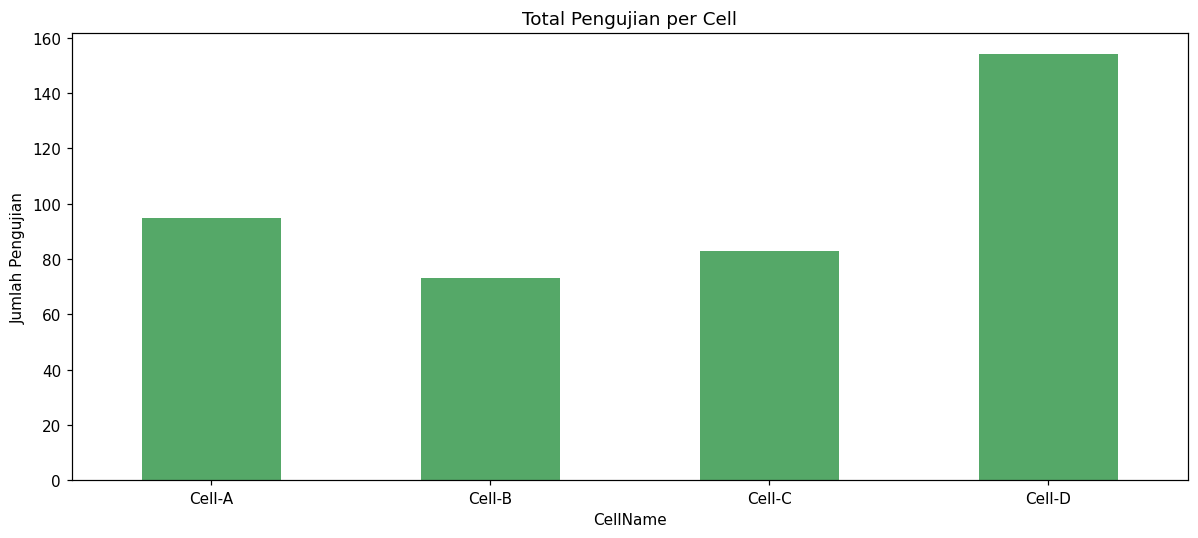

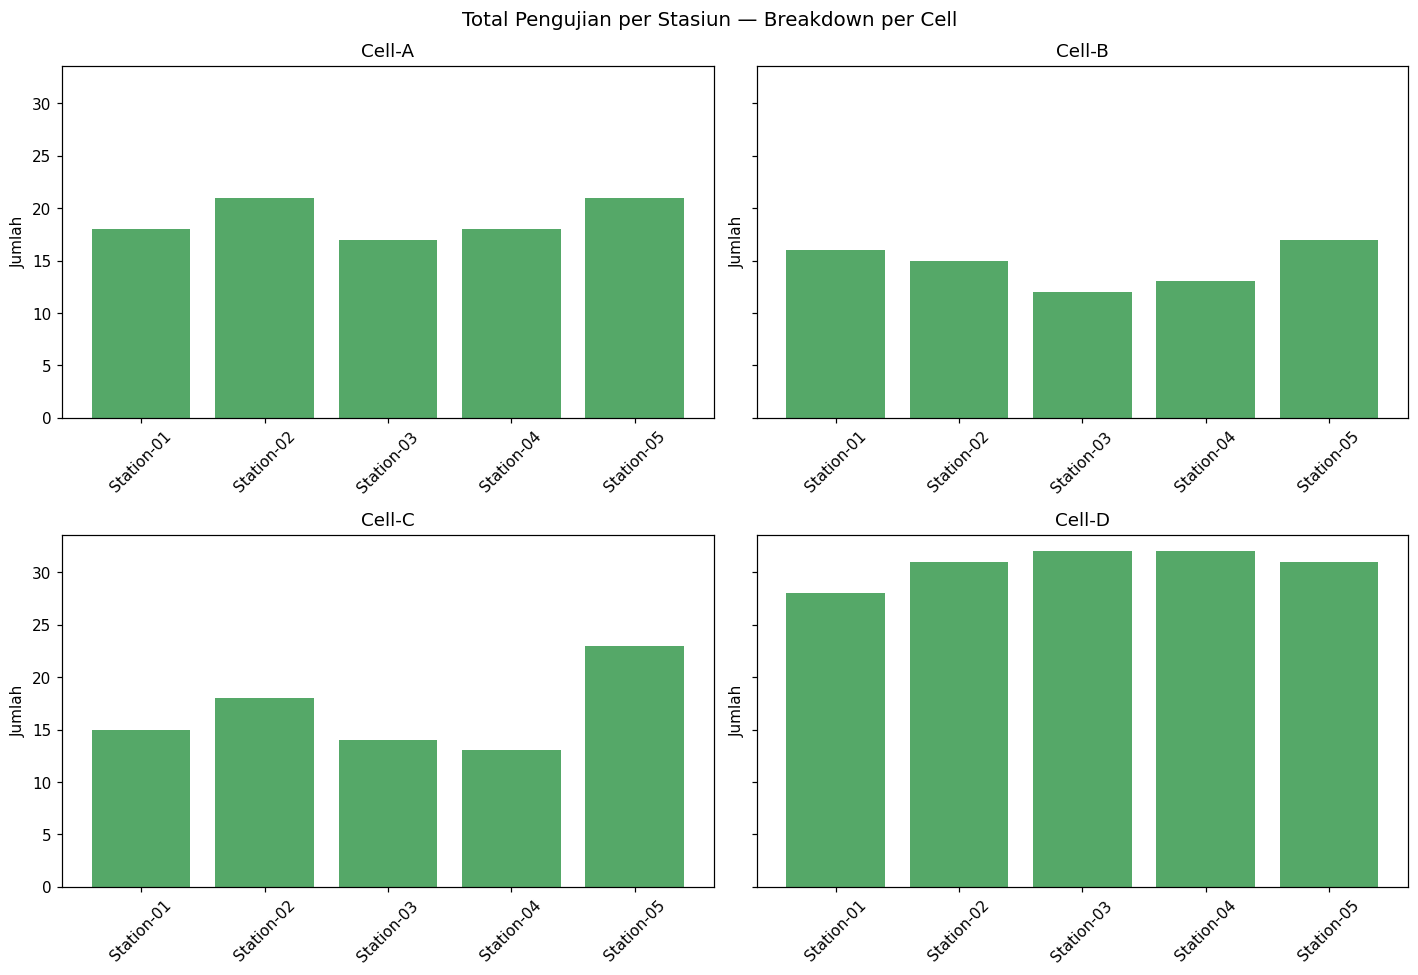

,Total_Test
CellName,
Cell-A,95
Cell-B,73
Cell-C,83
Cell-D,154


In [13]:
total_test_per_cell = df.groupby("CellName").size().reindex(cell_names)

plt.figure()
total_test_per_cell.plot(kind="bar", color="#55A868")
plt.ylabel("Jumlah Pengujian")
plt.title("Total Pengujian per Cell")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_per_cell(total_test, "Jumlah", "Total Pengujian per Stasiun — Breakdown per Cell", "#55A868")

total_test_per_cell.to_frame("Total_Test")


## 3. Waiting Time — Per Cell

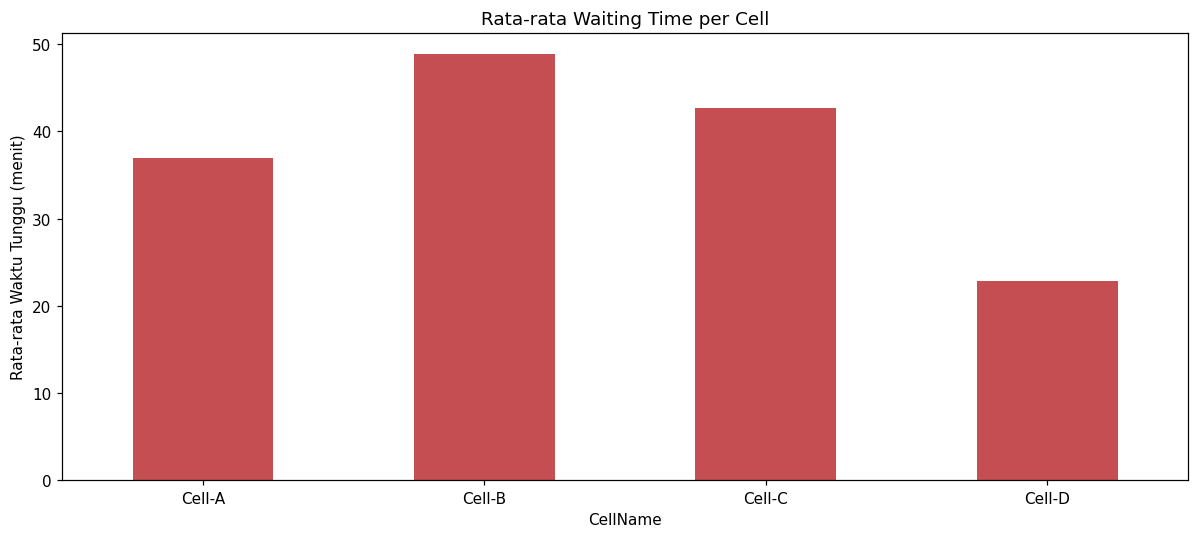

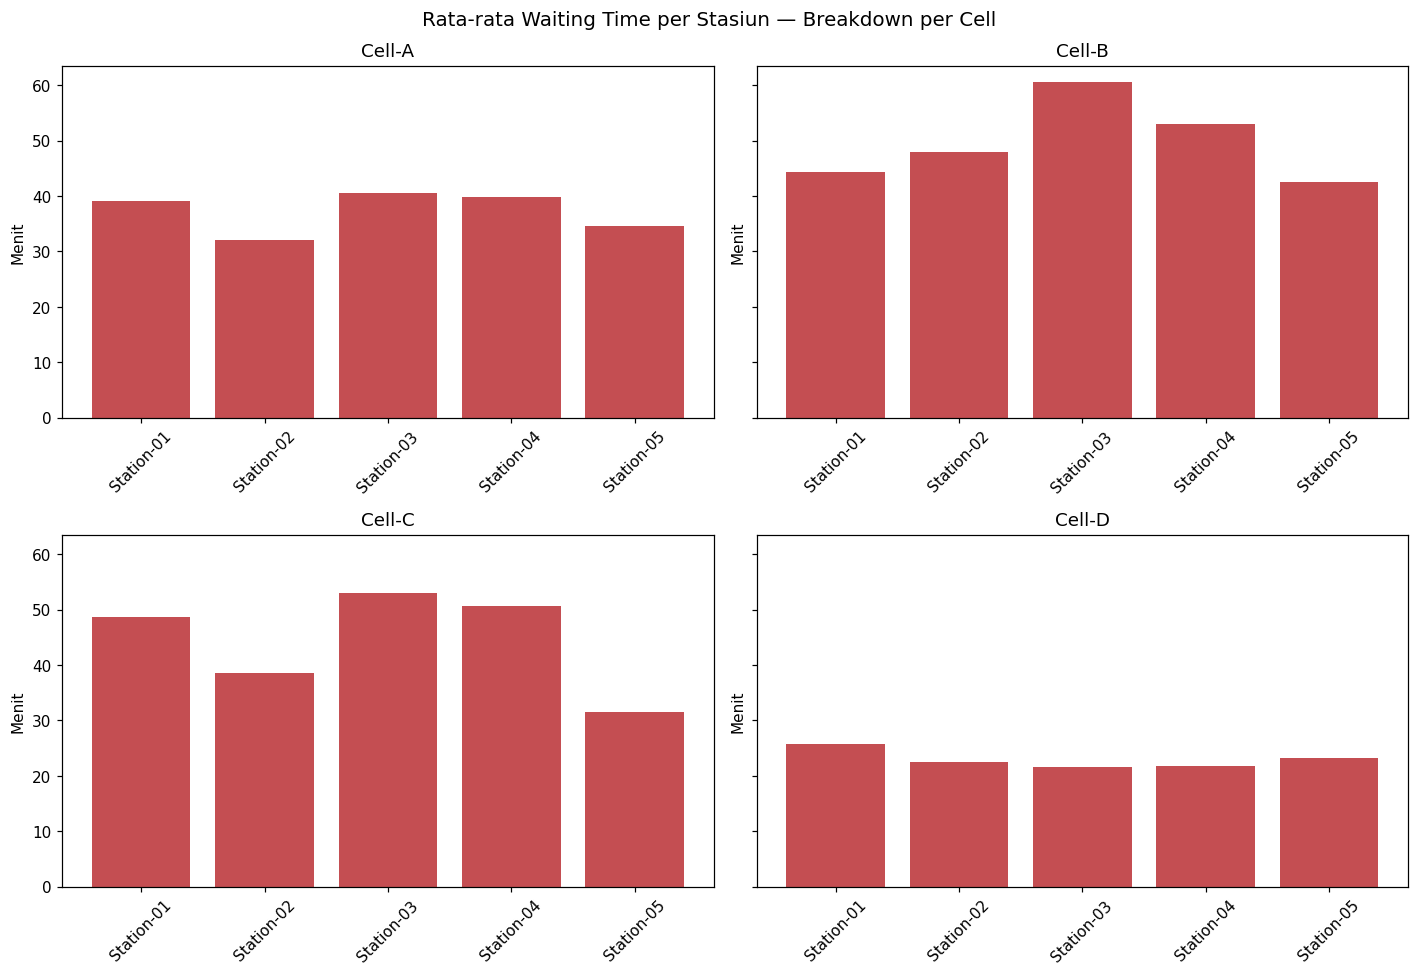

,Avg_WaitingTime_s
CellName,
Cell-A,2214.955556
Cell-B,2929.176471
Cell-C,2558.858974
Cell-D,1371.657718


In [14]:
waiting_per_cell = df_sorted.groupby("CellName")["WaitingTime_s"].mean().reindex(cell_names)

plt.figure()
(waiting_per_cell / 60).plot(kind="bar", color="#C44E52")
plt.ylabel("Rata-rata Waktu Tunggu (menit)")
plt.title("Rata-rata Waiting Time per Cell")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_per_cell(waiting_per_station, "Menit", "Rata-rata Waiting Time per Stasiun — Breakdown per Cell",
              "#C44E52", unit_divider=60)

waiting_per_cell.to_frame("Avg_WaitingTime_s")


## 4. Utilization — Per Cell

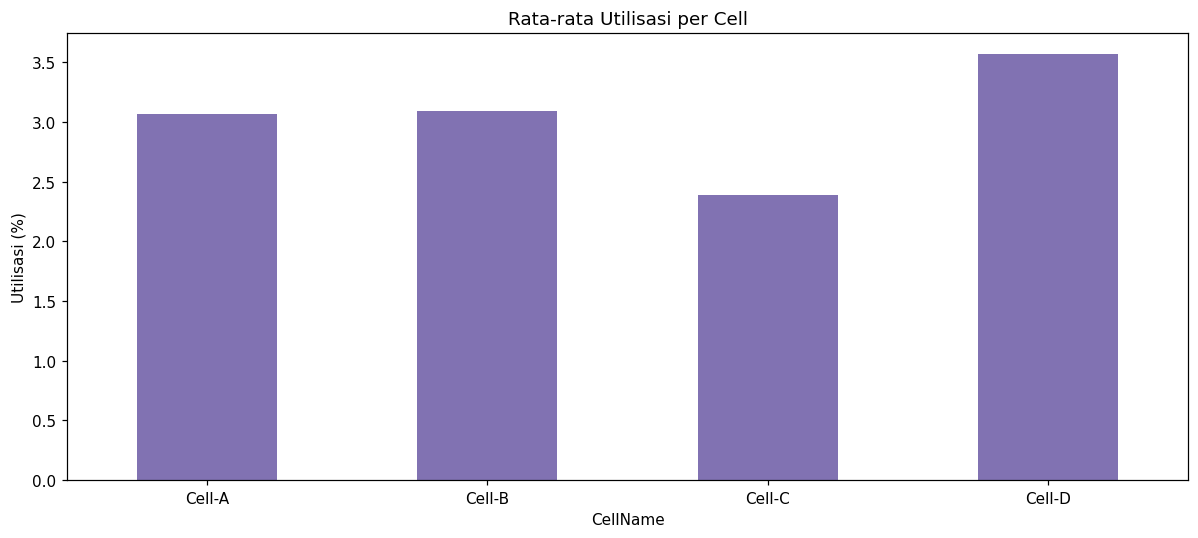

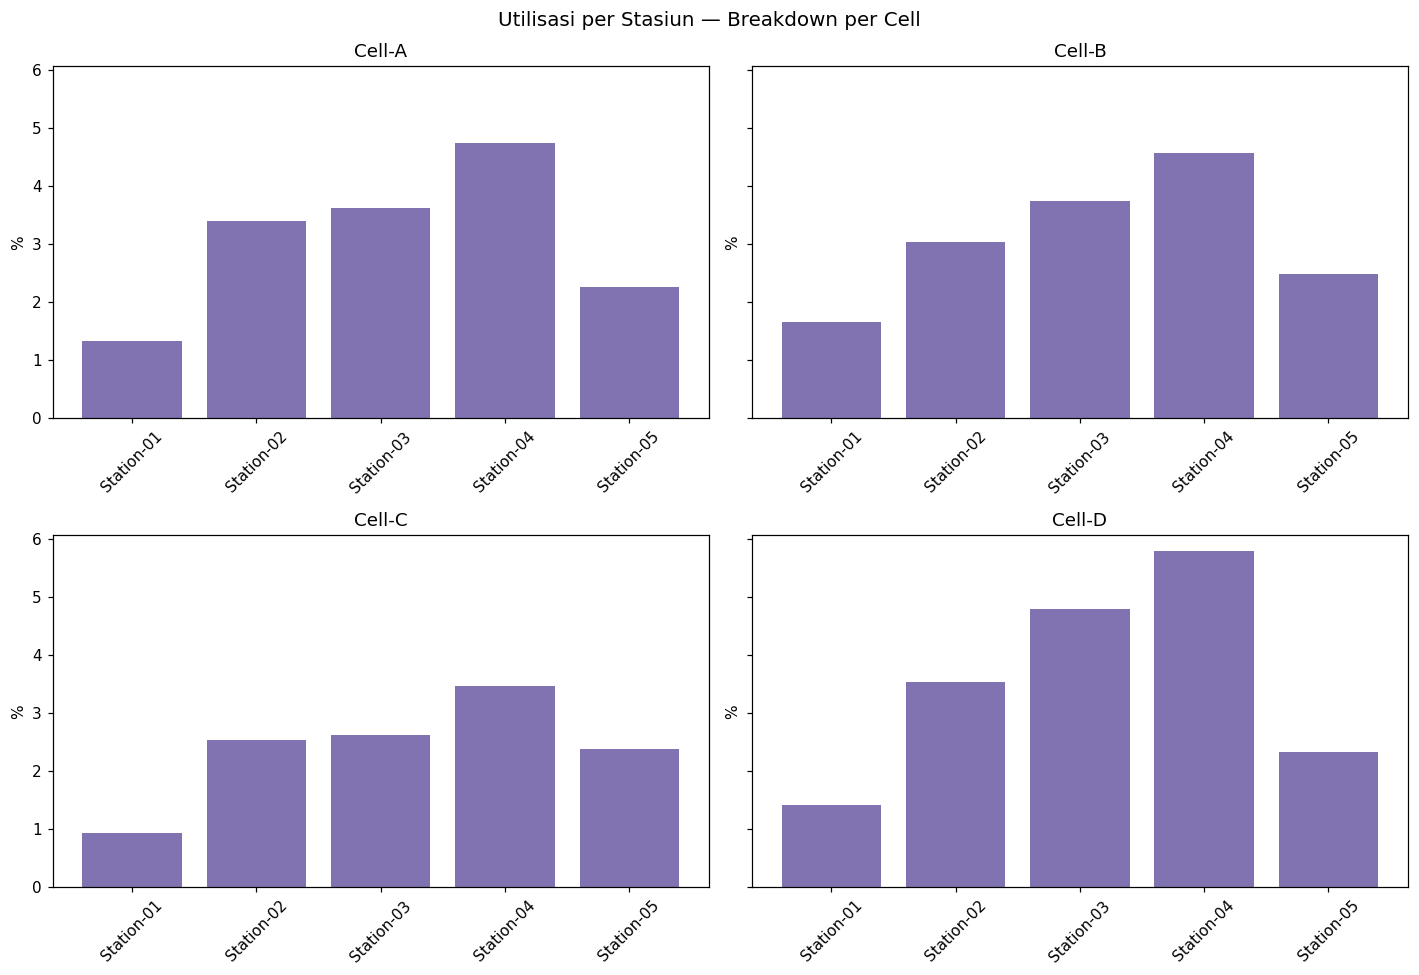

,Utilization_pct
CellName,
Cell-A,3.063009
Cell-B,3.090232
Cell-C,2.384277
Cell-D,3.563420


In [15]:
util_per_cell = span.groupby("StationLabel")["utilization_pct"]
cell_of_station = station_full.set_index("StationLabel")["CellName"]
util_by_cell_df = span.set_index("StationLabel")[["utilization_pct"]].join(cell_of_station)
utilization_per_cell = util_by_cell_df.groupby("CellName")["utilization_pct"].mean().reindex(cell_names)

plt.figure()
utilization_per_cell.plot(kind="bar", color="#8172B2")
plt.ylabel("Utilisasi (%)")
plt.title("Rata-rata Utilisasi per Cell")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plot_per_cell(util_per_station, "%", "Utilisasi per Stasiun — Breakdown per Cell", "#8172B2")

utilization_per_cell.to_frame("Utilization_pct")


## 5. Value-Add dan Non-Value-Add Time — Per Cell

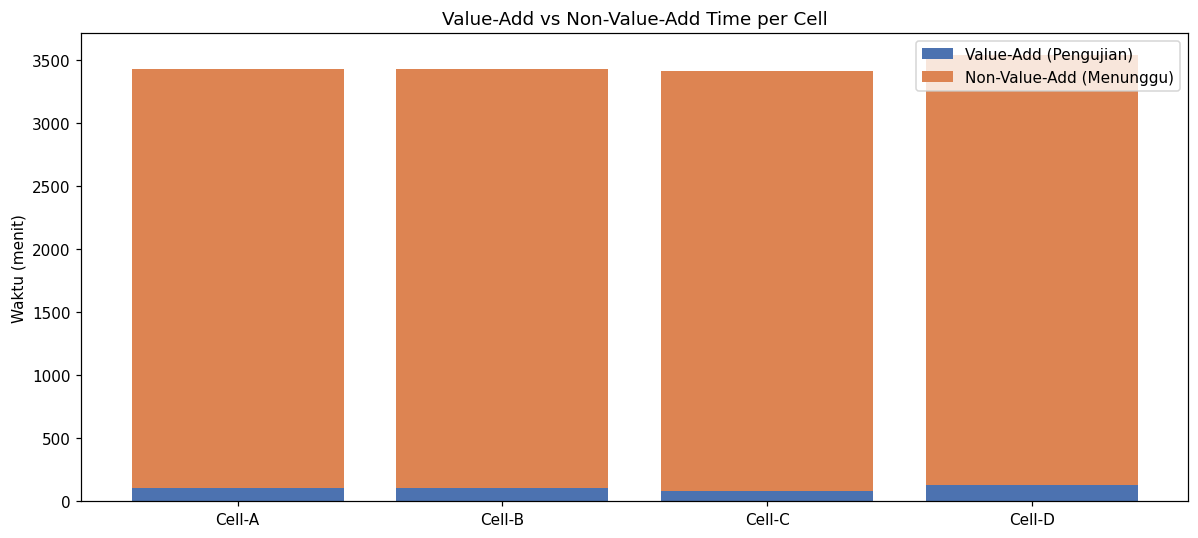

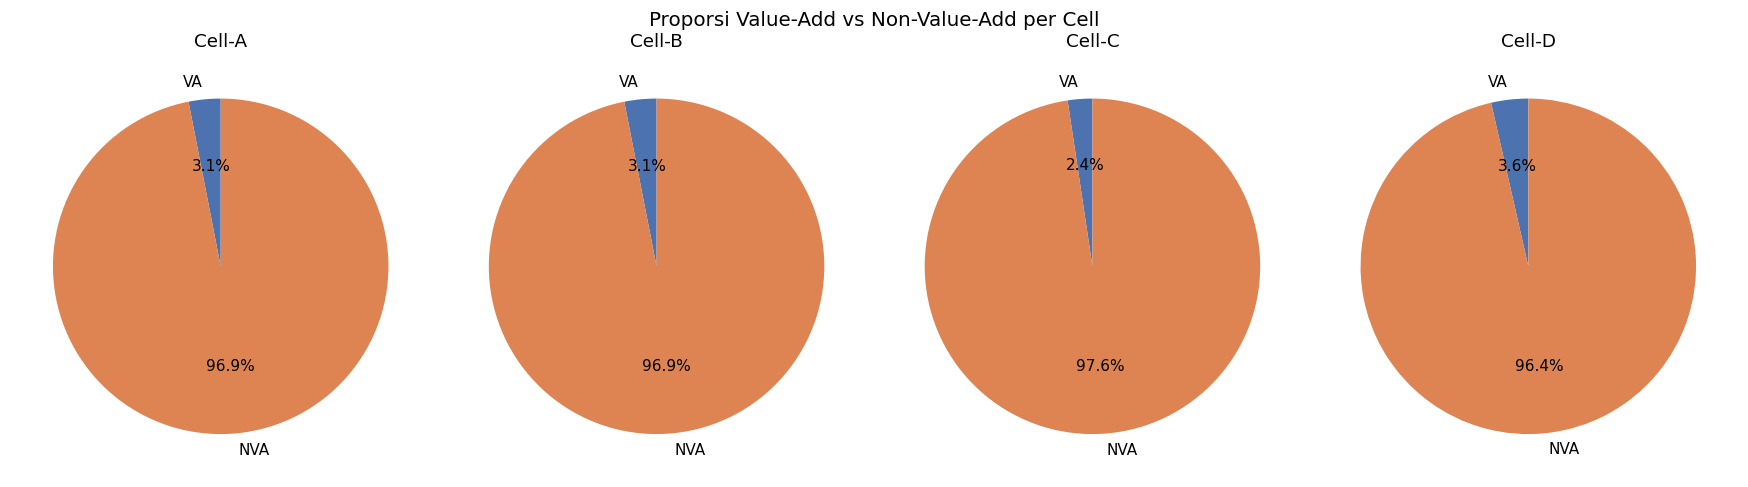

In [16]:
va_per_cell = df.groupby("CellName")["Duration_s"].sum().reindex(cell_names)
nva_per_cell = df_sorted.groupby("CellName")["WaitingTime_s"].sum().reindex(cell_names)

plt.figure()
plt.bar(cell_names, va_per_cell / 60, label="Value-Add (Pengujian)", color="#4C72B0")
plt.bar(cell_names, nva_per_cell / 60, bottom=va_per_cell / 60,
        label="Non-Value-Add (Menunggu)", color="#DD8452")
plt.ylabel("Waktu (menit)")
plt.title("Value-Add vs Non-Value-Add Time per Cell")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, cname in zip(axes, cell_names):
    va = va_per_cell.loc[cname]
    nva = nva_per_cell.loc[cname]
    ax.pie([va, nva], labels=["VA", "NVA"], autopct="%1.1f%%",
           colors=["#4C72B0", "#DD8452"], startangle=90)
    ax.set_title(cname)
fig.suptitle("Proporsi Value-Add vs Non-Value-Add per Cell", fontsize=13)
plt.tight_layout()
plt.show()


### Ringkasan Per Cell

In [17]:
summary_per_cell = pd.DataFrame({
    "Total_Test": total_test_per_cell,
    "Avg_Duration_s": avg_per_cell,
    "Avg_WaitingTime_s": waiting_per_cell,
    "Utilization_pct": utilization_per_cell,
    "Total_VA_s": va_per_cell,
    "Total_NVA_s": nva_per_cell,
}).round(2)

summary_per_cell


,Total_Test,Avg_Duration_s,Avg_WaitingTime_s,Utilization_pct,Total_VA_s,Total_NVA_s
CellName,,,,,,
Cell-A,95,66.52,2214.96,3.06,6319.0,199346.0
Cell-B,73,86.85,2929.18,3.09,6340.0,199184.0
Cell-C,83,58.29,2558.86,2.38,4838.0,199591.0
Cell-D,154,49.05,1371.66,3.56,7553.0,204377.0
